# Working with real image data
___

Lesson coursework from [PyTorch for Deep Learning with Python Bootcamp](#https://www.udemy.com/course/pytorch-for-deep-learning-with-python-bootcamp/) by Pierian Data & [Jose Portilla](#https://linkedin.com/in/jmportilla) (Head of Data Science at Pierian Training)


* When working with "real" image data, various preprocessing steps need to be taken before it is safe to work with it for machine learning experiments and projects.

  * This can include:

    * Aspect ration manipulation 
    * Scaling 
    * Normalization 
    * Transforming the images into Tensors

* When training machine learning models on images, it is also possible perform transformations in order to expand a dataset of unique images in order to increase the training set size to be efficient on resources. 

  * This can also be as simple as flipping an image horizontally, classifying it as a new image to the model.
    
    * Doing that for every image in the dataset for example, would double the size of your dataset.

In [1]:
# import packages

# deep learning library
import torch
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# data packages 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# ops packages 
import os
import imageio
from IPython.display import display
from pathlib import Path
import sys

# ignore versioning issues
import warnings
warnings.filterwarnings('ignore')

In [3]:

# confirm notebook kernel environment and path resolution
print('python executable:', sys.executable)
print('cwd:', Path.cwd())

python executable: /Users/aaronhowell/Documents/GitHub/machine-learning-projects/.venv/bin/python
cwd: /Users/aaronhowell/Documents/GitHub/machine-learning-projects/machine learning algorithms/working-with-image-data


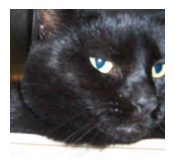

In [25]:
# display a single image
path = Path('../working-with-image-data/CATS_DOGS/test/CAT/9374.jpg')
img = imageio.imread(path)
plt.figure(figsize=(2,2))
plt.imshow(img)
plt.axis('off')
plt.show()

In [14]:
# prepare to create summary data
path = "/Users/aaronhowell/Documents/GitHub/machine-learning-projects/machine learning algorithms/working-with-image-data/CATS_DOGS"
img_names = []

for folder, subfolders, filenames in os.walk(path):
  for img in filenames:
    img_names.append(folder+'/'+img)

In [15]:
# check the number of images
len(img_names)

24994

In [26]:
# create a list of image sizes to get an idea of the data
img_sizes = []
rejected = []

for item in img_names:
  try:
    img = imageio.imread(item)
    height, width = img.shape[:2]
    img_sizes.append((width, height))
  except Exception as e:
    rejected.append((item, str(e)))

print('read:', len(img_sizes), 'failed:', len(rejected))
if rejected:
    print('Rejected files:')
    for item, error in rejected:
        print(f'  {item}: {error}')


read: 24994 failed: 0


In [27]:
df = pd.DataFrame(img_sizes)

In [33]:
df.head()

,0,1
0,365,500
1,484,500
2,448,500
3,500,483
4,500,375


In [34]:
# look at the distribution of widths of the images
display(df[0].describe())

count    24994.000000
mean       404.493518
std        108.941802
min         42.000000
25%        323.000000
50%        448.000000
75%        500.000000
max        500.000000
Name: 0, dtype: float64

In [35]:
# look at the distribution of heights of the images
display(df[1].describe())

count    24994.000000
mean       361.037129
std         96.936811
min         33.000000
25%        302.000000
50%        375.000000
75%        421.000000
max        500.000000
Name: 1, dtype: float64

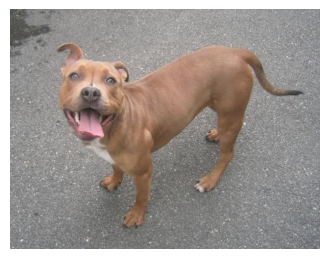

In [47]:
# display an image of a dog from the training set
path = "../working-with-image-data/CATS_DOGS/train/DOG/14.jpg"
dog = imageio.imread(path)
plt.figure(figsize=(4,4))
plt.imshow(dog)
plt.axis('off')
plt.show()